# IMPORT DATA & LIBRARY

In [59]:
from google.colab import files

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.6 MB/s eta 0:00:00


In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from scipy.stats import randint, uniform

import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
!pip install koreanize-matplotlib

import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 46.9 MB/s eta 0:00:00


In [45]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df['is_train'] = True
test_df['is_train'] = False
test_df['성공확률'] = np.nan
combined = pd.concat([train_df, test_df], ignore_index=True)

# EDA

In [8]:
train_df.head()

,ID,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률
0,TRAIN_0000,2009,CT005,이커머스,Series A,4126.0,No,No,56.0,3365.0,4764.0,4.71,NaN,0.3
1,TRAIN_0001,2023,CT006,핀테크,Seed,4167.0,Yes,No,80.0,4069.0,279.0,1.00,2500-3500,0.8
2,TRAIN_0002,2018,CT007,기술,Series A,3132.0,Yes,Yes,54.0,6453.0,12141.0,4.00,3500-4500,0.5
3,TRAIN_0003,2016,CT006,NaN,Seed,3245.0,Yes,Yes,NaN,665.0,10547.0,2.97,NaN,0.7
4,TRAIN_0004,2020,CT002,에듀테크,Seed,1969.0,No,Yes,94.0,829.0,9810.0,1.00,1500-2500,0.1


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   분야              3519 non-null   object 
 4   투자단계            4376 non-null   object 
 5   직원 수            4202 non-null   float64
 6   인수여부            4376 non-null   object 
 7   상장여부            4376 non-null   object 
 8   고객수(백만명)        3056 non-null   float64
 9   총 투자금(억원)       4376 non-null   float64
 10  연매출(억원)         4376 non-null   float64
 11  SNS 팔로워 수(백만명)  4376 non-null   float64
 12  기업가치(백억원)       3156 non-null   object 
 13  성공확률            4376 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 478.8+ KB


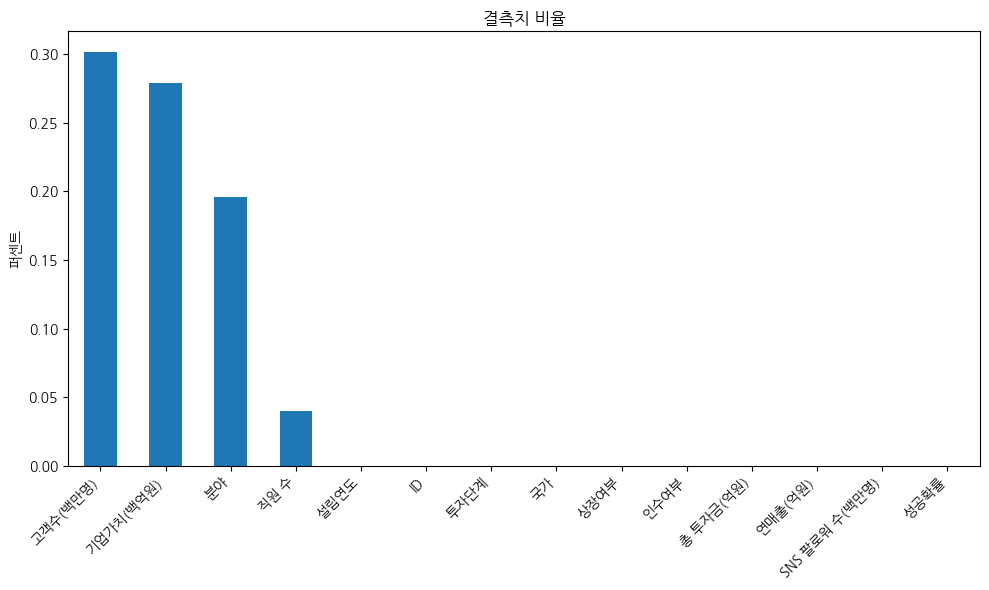

In [13]:
missing_values = train_df.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar')
plt.title("결측치 비율")
plt.ylabel("퍼센트")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

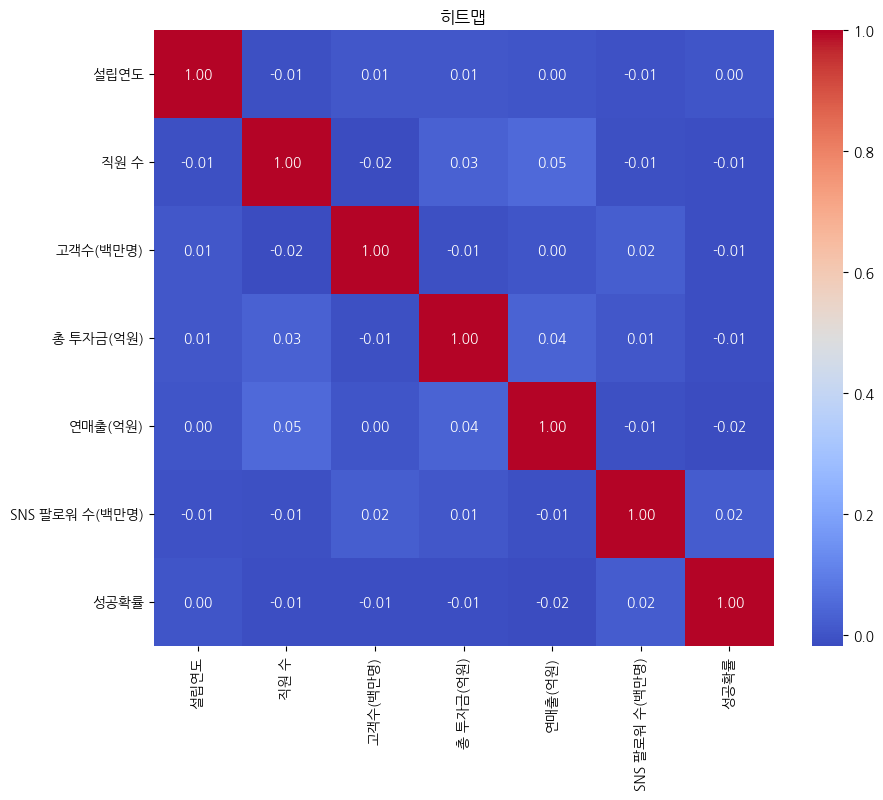

In [17]:
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("히트맵")
plt.show()

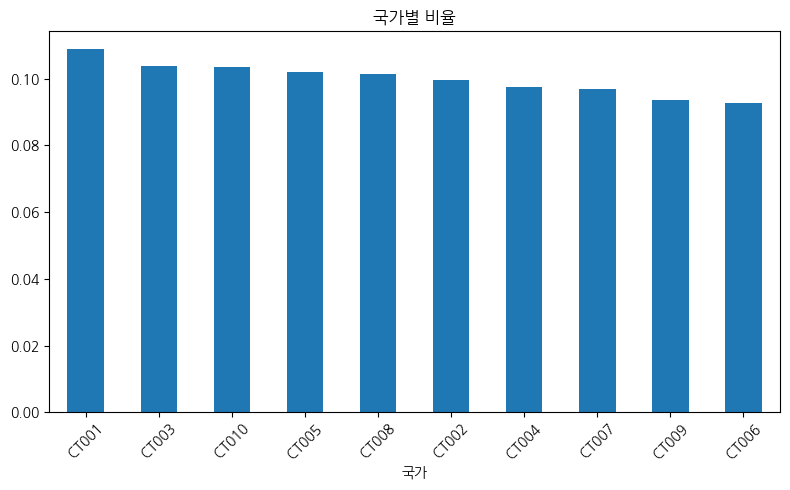

In [20]:
# 국가별 비율 계산
object_ratio = train_df["국가"].value_counts(normalize=True)

plt.figure(figsize=(8, 5))
object_ratio.plot(kind='bar')
plt.title("국가별 비율")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

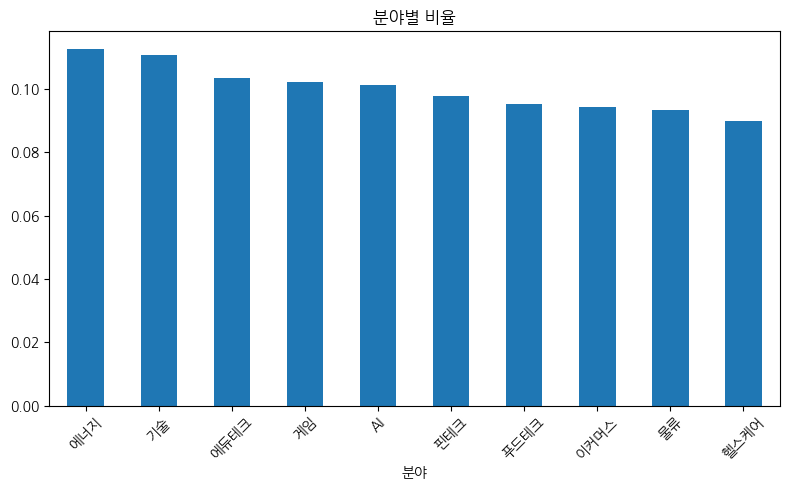

In [21]:
# 분야별 비율 계산
object_ratio = train_df["분야"].value_counts(normalize=True)

plt.figure(figsize=(8, 5))
object_ratio.plot(kind='bar')
plt.title("분야별 비율")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

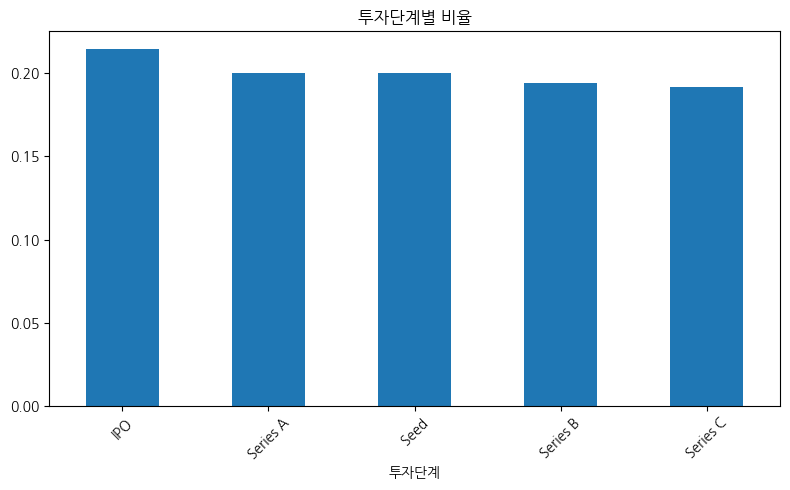

In [22]:
# 투자단계별 비율 계산
object_ratio = train_df["투자단계"].value_counts(normalize=True)

# 그래프 그리기
plt.figure(figsize=(8, 5))
object_ratio.plot(kind='bar')
plt.title("투자단계별 비율")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# DATA PROCESSING

In [46]:
# 기업가치 전처리
def parse_value(x):
    if pd.isna(x):
        return np.nan
    if '-' in x:
        a, b = x.split('-')
        return (int(a) + int(b)) / 2
    elif '이상' in x:
        return float(x.replace('이상', '')) + 500
    return float(x)

combined['기업가치(백억원)'] = combined['기업가치(백억원)'].apply(parse_value)

In [47]:
# 수치형 결측치 중앙값 대체
num_cols = combined.select_dtypes(include=['float64', 'int64']).columns.drop(['성공확률'])
num_imputer = SimpleImputer(strategy='median')
combined[num_cols] = num_imputer.fit_transform(combined[num_cols])

# 범주형 라벨 인코딩
cat_cols = combined.select_dtypes(include='object').columns.drop('ID')
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))
    label_encoders[col] = le

# MODEL

In [49]:
# 분리
train_processed = combined[combined['is_train']].drop(columns=['is_train'])
test_processed = combined[~combined['is_train']].drop(columns=['is_train', '성공확률'])

X = train_processed.drop(columns=['ID', '성공확률'])
y = train_processed['성공확률']
X_test = test_processed.drop(columns=['ID'])

# Weighted MAE 정의
def weighted_mae(y_true, y_pred):
    weights = np.ones_like(y_true)  # 필요 시 가중치 커스터마이징 가능
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
# Random Forest
rf = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}
rf_search = RandomizedSearchCV(rf, rf_params, n_iter=10, cv=3,
                                scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
rf_pred = rf_best.predict(X_val)
rf_score = weighted_mae(y_val, rf_pred)

print(f"Random Forest Weighted MAE: {rf_score:.5f}")

In [51]:
# CatBoost
cat = CatBoostRegressor(verbose=0, random_state=42)
cat_params = {
    'depth': randint(4, 10),
    'learning_rate': uniform(0.01, 0.3),
    'iterations': randint(100, 500)
}
cat_search = RandomizedSearchCV(cat, cat_params, n_iter=10, cv=3,
                                scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
cat_search.fit(X_train, y_train)
cat_best = cat_search.best_estimator_
cat_pred = cat_best.predict(X_val)
cat_score = weighted_mae(y_val, cat_pred)

print(f"CatBoost Weighted MAE: {cat_score:.5f}")

In [55]:
# 최종 모델 선택
best_model = cat_best if cat_score < rf_score else rf_best
final_pred = best_model.predict(X_test)

# 결과 저장
submission = pd.DataFrame({
    'ID': test_processed['ID'],
    '성공확률': final_pred
})
submission.to_csv("prediction_result.csv", index=False)
files.download("prediction_result.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>